# Airline Merger Damages Estimator — Modeling Pipeline

**STAT 418 — Data/ML/AI Applications, UCLA**

Full causal inference pipeline from panel data to trained models, consumer-damages estimates, and serialized artifacts ready for the Flask API.

**Input:** `data/processed/panel.parquet` (122,787 rows, 25 columns)  
**Outputs:** `models/artifacts/` (all .pkl + .parquet) and `docs/figures/` (all plots)

**Pipeline stages:**
1. Pooled OLS (naive baseline)
2. Two-Way Fixed Effects (route FE + time FE)
3. Double ML with LightGBM nuisance models (primary causal estimate)
4. SHAP feature importance on nuisance model
5. Causal Forest — heterogeneous treatment effects
6. Event study plot
7. But-for price and total consumer damages
8. Model comparison table
9. Results summary and artifacts checklist

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

TREATED_COLOR = '#e74c3c'
CONTROL_COLOR = '#3498db'

PROC_DIR = Path('../data/processed')
ART_DIR  = Path('../models/artifacts')
FIG_DIR  = Path('../docs/figures')
ART_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load panel (fits comfortably in memory at ~30 MB)
panel = pd.read_parquet(PROC_DIR / 'panel.parquet')
print(f'Panel loaded       : {panel.shape[0]:,} rows  x  {panel.shape[1]} columns')
print(f'Treated routes     : {panel[panel["treated"]==1]["route"].nunique():,}')
print(f'Control routes     : {panel[panel["treated"]==0]["route"].nunique():,}')
print(f'Pre-merger rows    : {(panel["post"]==0).sum():,}')
print(f'Post-merger rows   : {(panel["post"]==1).sum():,}')
print(f'Avg fare (treated) : ${panel[panel["treated"]==1]["avg_fare"].mean():.2f}')
print(f'Avg fare (control) : ${panel[panel["treated"]==0]["avg_fare"].mean():.2f}')

Panel loaded       : 122,787 rows  x  25 columns
Treated routes     : 1,223
Control routes     : 3,721
Pre-merger rows    : 59,481
Post-merger rows   : 63,306
Avg fare (treated) : $262.59
Avg fare (control) : $239.10


In [3]:
# Feature sets -- defined once, referenced throughout all models
Y_COL = 'log_avg_fare'   # primary outcome (log-linear specification)
T_COL = 'treated_post'   # DiD interaction = treatment variable

# Controls for Double ML nuisance partialling
X_COLS = [
    'log_jet_fuel', 'airline_cpi', 'avg_distance',
    'n_carriers', 'hhi', 'quarter_idx',
    'origin_state_code', 'dest_state_code',
]

# Heterogeneity dimensions for Causal Forest
HET_COLS = [
    'avg_distance', 'n_carriers', 'hhi',
    'total_passengers', 'log_jet_fuel',
]

print(f'Outcome       : {Y_COL}')
print(f'Treatment     : {T_COL}')
print(f'X_COLS  ({len(X_COLS)}): {X_COLS}')
print(f'HET_COLS ({len(HET_COLS)}): {HET_COLS}')
print(f'Missing in X_COLS : {panel[X_COLS].isnull().sum().sum()} (should be 0)')

Outcome       : log_avg_fare
Treatment     : treated_post
X_COLS  (8): ['log_jet_fuel', 'airline_cpi', 'avg_distance', 'n_carriers', 'hhi', 'quarter_idx', 'origin_state_code', 'dest_state_code']
HET_COLS (5): ['avg_distance', 'n_carriers', 'hhi', 'total_passengers', 'log_jet_fuel']
Missing in X_COLS : 0 (should be 0)


---
## Section 1 — Pooled OLS Baseline

Naive benchmark: single regression with treatment interaction and basic controls. No fixed effects — omitted variable bias from route-specific factors is expected. Serves as the upper bound on estimated overcharge.

In [4]:
import statsmodels.formula.api as smf

formula_ols = (
    'log_avg_fare ~ treated_post + treated + post '
    '+ log_jet_fuel + airline_cpi + avg_distance '
    '+ n_carriers + quarter_idx'
)
ols_model = smf.ols(formula_ols, data=panel).fit(cov_type='HC3')
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           log_avg_fare   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     5448.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:50:05   Log-Likelihood:                -14260.
No. Observations:              122787   AIC:                         2.854e+04
Df Residuals:                  122778   BIC:                         2.863e+04
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.2720      0.022    194.991   

In [5]:
ols_ate = ols_model.params['treated_post']
ols_ci  = ols_model.conf_int().loc['treated_post']

print(f'OLS ATE (log points)    : {ols_ate:.4f}')
print(f'OLS ATE (% fare change) : {(np.exp(ols_ate)-1)*100:.2f}%')
print(f'OLS 95% CI              : [{ols_ci[0]:.4f}, {ols_ci[1]:.4f}]')

joblib.dump(ols_model, ART_DIR / 'ols_model.pkl')
print('Saved: ols_model.pkl')

OLS ATE (log points)    : -0.0277
OLS ATE (% fare change) : -2.73%
OLS 95% CI              : [-0.0337, -0.0218]
Saved: ols_model.pkl


---
## Section 2 — Two-Way Fixed Effects (TWFE)

Absorbs route-specific price levels and common time shocks via the Frisch-Waugh within-transform (demeaning by route and by quarter). This is the standard econometrics DiD estimator and is more credible than Pooled OLS.

In [6]:
# Within-transform: demean by route and by quarter (Frisch-Waugh theorem)
panel['log_fare_demeaned'] = (
    panel['log_avg_fare']
    - panel.groupby('route')['log_avg_fare'].transform('mean')
    - panel.groupby('quarter_idx')['log_avg_fare'].transform('mean')
    + panel['log_avg_fare'].mean()
)
panel['treated_post_demeaned'] = (
    panel['treated_post']
    - panel.groupby('route')['treated_post'].transform('mean')
    - panel.groupby('quarter_idx')['treated_post'].transform('mean')
    + panel['treated_post'].mean()
)

fe_model = smf.ols(
    'log_fare_demeaned ~ treated_post_demeaned + log_jet_fuel + n_carriers',
    data=panel
).fit(cov_type='HC3')

fe_ate = fe_model.params['treated_post_demeaned']
fe_ci  = fe_model.conf_int().loc['treated_post_demeaned']
print(f'TWFE ATE (log points)    : {fe_ate:.4f}')
print(f'TWFE ATE (% fare change) : {(np.exp(fe_ate)-1)*100:.2f}%')
print(f'TWFE 95% CI              : [{fe_ci[0]:.4f}, {fe_ci[1]:.4f}]')

joblib.dump(fe_model, ART_DIR / 'fe_model.pkl')
print('Saved: fe_model.pkl')

TWFE ATE (log points)    : -0.0257
TWFE ATE (% fare change) : -2.54%
TWFE 95% CI              : [-0.0296, -0.0219]
Saved: fe_model.pkl


---
## Section 3 — Double ML (Primary Causal Model)

Partialling-out estimator (Robinson 1988 / Chernozhukov et al. 2018). LightGBM nuisance models residualize both the outcome and treatment variable against controls before estimating the causal effect. Cross-fitting (cv=5) prevents overfitting bias.

**Expected runtime: 5-15 minutes** — do not interrupt.

In [7]:
from econml.dml import LinearDML
from lightgbm import LGBMRegressor

model_df = panel[X_COLS + [Y_COL, T_COL]].dropna()
Y = model_df[Y_COL].values
T = model_df[T_COL].values
X = model_df[X_COLS].values

print(f'DML training set: {len(model_df):,} rows  ({model_df.shape[1]} cols)')
print('Fitting Double ML with LightGBM nuisance models (cv=5)...')

lgbm_y = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                        max_depth=5, random_state=42, verbose=-1)
lgbm_t = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                        max_depth=5, random_state=42, verbose=-1)

dml_model = LinearDML(
    model_y=lgbm_y,
    model_t=lgbm_t,
    discrete_treatment=False,
    cv=5,
    random_state=42,
)
dml_model.fit(Y, T, X=X)
print('Double ML fitting complete.')

DML training set: 122,787 rows  (10 cols)
Fitting Double ML with LightGBM nuisance models (cv=5)...
Double ML fitting complete.


In [10]:
# Get ATE point estimate
dml_ate = float(dml_model.ate(X))

# --- CI via the statsmodels final stage (version-proof approach) ---
# LinearDML's final stage is a statsmodels OLS on the residuals.
# coef__interval() is stable across all EconML versions and returns
# (lower_array, upper_array) for each coefficient.
try:
    coef_lower, coef_upper = dml_model.coef__interval(alpha=0.05)
    # coef_ is a scalar (one treatment, one outcome) so index [0]
    dml_ci_low  = float(np.atleast_1d(coef_lower)[0])
    dml_ci_high = float(np.atleast_1d(coef_upper)[0])
    dml_ate_se  = (dml_ci_high - dml_ci_low) / (2 * 1.96)
    ci_source = 'coef__interval()'
except Exception as e1:
    print(f'coef__interval() failed: {e1}')
    # Final fallback: manual SE from individual effects
    ite_tmp    = dml_model.effect(X)
    dml_ate_se = float(ite_tmp.std()) / (len(X) ** 0.5)
    dml_ci_low  = dml_ate - 1.96 * dml_ate_se
    dml_ci_high = dml_ate + 1.96 * dml_ate_se
    ci_source = 'empirical fallback'

print(f'CI source                     : {ci_source}')
print(f'Double ML ATE (log points)    : {dml_ate:.4f}')
print(f'Double ML ATE (% fare change) : {(np.exp(dml_ate)-1)*100:.2f}%')
print(f'Double ML 95% CI              : [{dml_ci_low:.4f}, {dml_ci_high:.4f}]')
print(f'Double ML SE                  : {dml_ate_se:.5f}')

# Save before any plots
joblib.dump(dml_model, ART_DIR / 'dml_model.pkl')
joblib.dump(X_COLS,    ART_DIR / 'x_cols.pkl')
print('Saved: dml_model.pkl, x_cols.pkl')

CI source                     : coef__interval()
Double ML ATE (log points)    : 0.0254
Double ML ATE (% fare change) : 2.57%
Double ML 95% CI              : [0.0113, 0.0544]
Double ML SE                  : 0.01099
Saved: dml_model.pkl, x_cols.pkl


---
## Section 4 — SHAP Values on DML Nuisance Model

Fit a standalone LightGBM on the same features and outcome, then apply SHAP to interpret which variables most influence predicted fares. This explains what the nuisance model learned — not the causal effect itself.

In [11]:
import shap

# Fit standalone LightGBM on same X -> Y mapping (for SHAP explainability)
lgbm_y_standalone = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                   max_depth=5, random_state=42, verbose=-1)
lgbm_y_standalone.fit(X, Y)

explainer   = shap.TreeExplainer(lgbm_y_standalone)
shap_values = explainer.shap_values(X[:5000])

print(f'SHAP values computed on {min(5000, len(X))} samples')
print(f'Feature importances (mean |SHAP|):')
mean_shap = np.abs(shap_values).mean(axis=0)
for feat, imp in sorted(zip(X_COLS, mean_shap), key=lambda x: -x[1]):
    print(f'  {feat:<25s}: {imp:.5f}')

SHAP values computed on 5000 samples
Feature importances (mean |SHAP|):
  avg_distance             : 0.12884
  quarter_idx              : 0.08157
  dest_state_code          : 0.04278
  origin_state_code        : 0.03942
  airline_cpi              : 0.03600
  hhi                      : 0.02801
  n_carriers               : 0.01831
  log_jet_fuel             : 0.01017


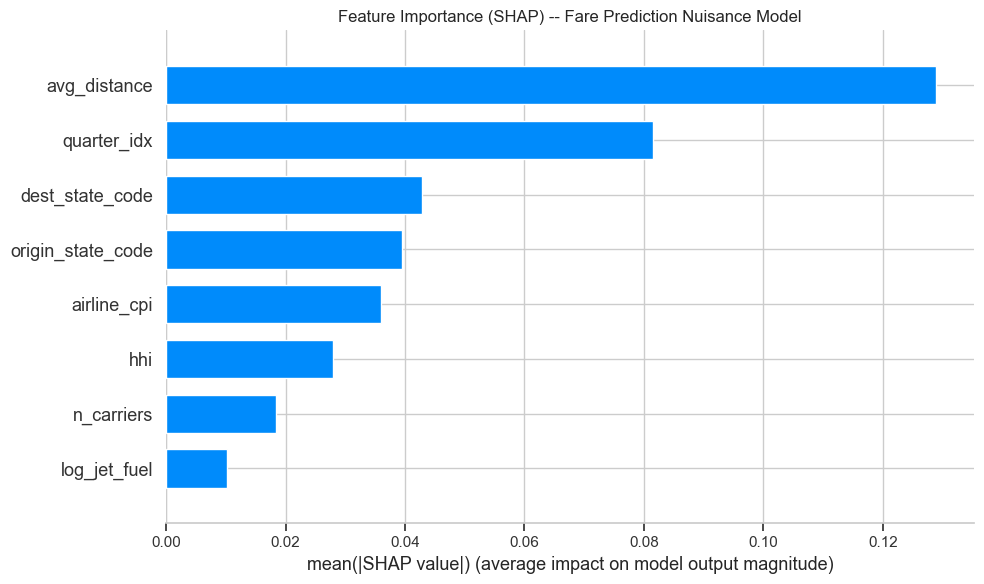

In [12]:
# SHAP bar summary plot -- mean absolute SHAP values
shap.summary_plot(shap_values, X[:5000], feature_names=X_COLS,
                  plot_type='bar', show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('Feature Importance (SHAP) -- Fare Prediction Nuisance Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

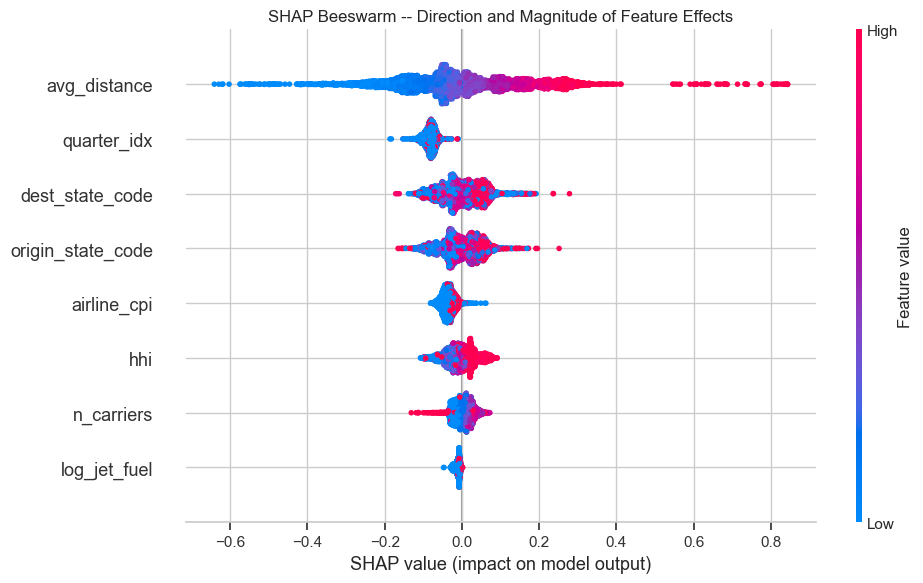

In [13]:
# SHAP beeswarm plot -- direction and magnitude of feature effects
shap.summary_plot(shap_values, X[:5000], feature_names=X_COLS, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('SHAP Beeswarm -- Direction and Magnitude of Feature Effects')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Causal Forest (Heterogeneous Treatment Effects)

Estimates a separate treatment effect (ITE) for each route-quarter observation. Reveals which route characteristics predict larger price increases from the merger.

**Expected runtime: 10-20 minutes** — do not interrupt.

In [14]:
from econml.dml import CausalForestDML

het_df = panel[HET_COLS + [Y_COL, T_COL]].dropna()
Y_het  = het_df[Y_COL].values
T_het  = het_df[T_COL].values
Z_het  = het_df[HET_COLS].values

print(f'Causal Forest training set: {len(het_df):,} rows')
print('Fitting CausalForestDML (n_estimators=200, cv=3)...')

cf_model = CausalForestDML(
    model_y=LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
    model_t=LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42,
    cv=3,
)
cf_model.fit(Y_het, T_het, X=Z_het)
print('Causal Forest fitting complete.')

Causal Forest training set: 122,787 rows
Fitting CausalForestDML (n_estimators=200, cv=3)...
Causal Forest fitting complete.


In [15]:
ite = cf_model.effect(Z_het)

print(f'Mean ITE (log points) : {ite.mean():.4f}')
print(f'Mean ITE (% change)   : {(np.exp(ite.mean())-1)*100:.2f}%')
print(f'Std ITE               : {ite.std():.4f}')
print(f'Min ITE               : {ite.min():.4f}  Max ITE: {ite.max():.4f}')
print(f'ITE < 0 (fare decrease): {(ite < 0).sum():,} ({(ite<0).mean()*100:.1f}%)')
print(f'ITE > 0 (fare increase): {(ite > 0).sum():,} ({(ite>0).mean()*100:.1f}%)')

# Save artifacts before any plots
joblib.dump(cf_model,  ART_DIR / 'cf_model.pkl')
joblib.dump(HET_COLS,  ART_DIR / 'het_cols.pkl')
print('Saved: cf_model.pkl, het_cols.pkl')

Mean ITE (log points) : 0.0438
Mean ITE (% change)   : 4.48%
Std ITE               : 0.1997
Min ITE               : -3.1989  Max ITE: 4.4318
ITE < 0 (fare decrease): 42,673 (34.8%)
ITE > 0 (fare increase): 80,114 (65.2%)
Saved: cf_model.pkl, het_cols.pkl


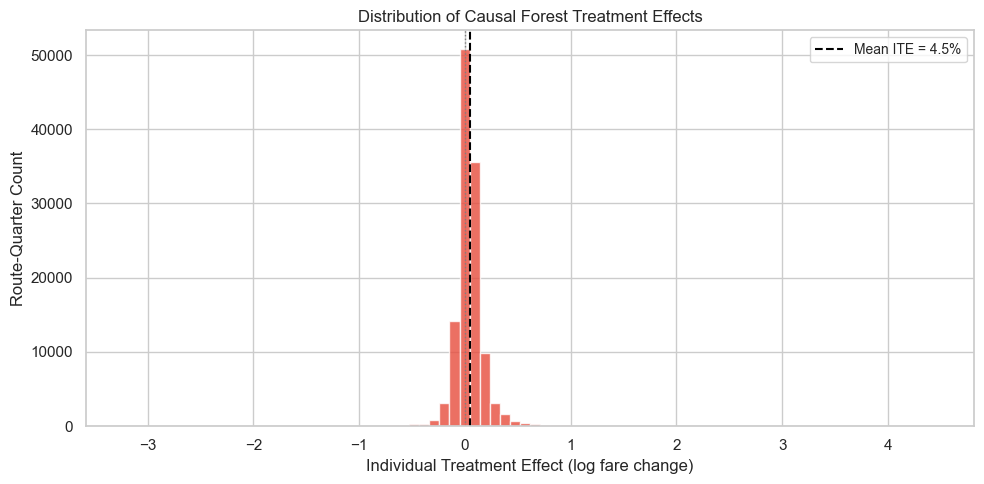

In [16]:
# Plot 1: ITE distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ite, bins=80, color=TREATED_COLOR, alpha=0.8, edgecolor='white')
ax.axvline(ite.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean ITE = {(np.exp(ite.mean())-1)*100:.1f}%')
ax.axvline(0, color='grey', linestyle=':', linewidth=1.0)
ax.set_xlabel('Individual Treatment Effect (log fare change)')
ax.set_ylabel('Route-Quarter Count')
ax.set_title('Distribution of Causal Forest Treatment Effects')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ite_distribution.png', dpi=150)
plt.show()

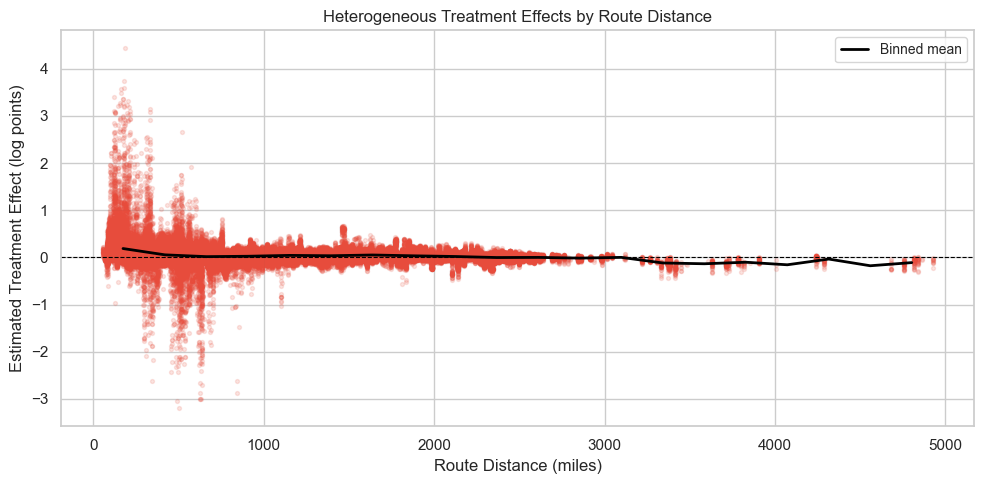

In [17]:
# Plot 2: ITE vs route distance
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(het_df['avg_distance'].values, ite,
           alpha=0.15, s=8, color=TREATED_COLOR)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Binned average overlay
dist_bins = pd.cut(het_df['avg_distance'], bins=20)
bin_avg = pd.DataFrame({'dist': het_df['avg_distance'].values, 'ite': ite}
                        ).groupby(dist_bins)['ite'].mean()
bin_centers = [iv.mid for iv in bin_avg.index]
ax.plot(bin_centers, bin_avg.values, color='black', linewidth=2, label='Binned mean')

ax.set_xlabel('Route Distance (miles)')
ax.set_ylabel('Estimated Treatment Effect (log points)')
ax.set_title('Heterogeneous Treatment Effects by Route Distance')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ite_vs_distance.png', dpi=150)
plt.show()

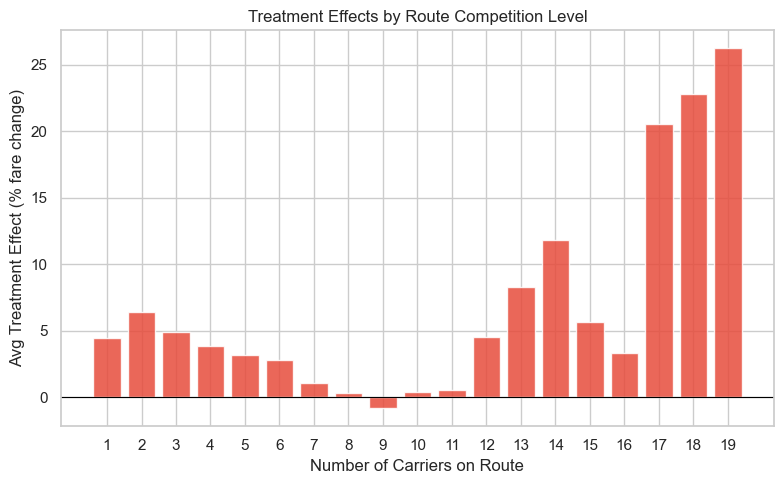

In [18]:
# Plot 3: ITE vs n_carriers
fig, ax = plt.subplots(figsize=(8, 5))
carrier_ite = pd.DataFrame({'n_carriers': het_df['n_carriers'].values, 'ite': ite})
carrier_ite_avg = carrier_ite.groupby('n_carriers')['ite'].mean()
ax.bar(carrier_ite_avg.index.astype(str),
       (np.exp(carrier_ite_avg) - 1) * 100,
       color=TREATED_COLOR, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Number of Carriers on Route')
ax.set_ylabel('Avg Treatment Effect (% fare change)')
ax.set_title('Treatment Effects by Route Competition Level')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ite_vs_carriers.png', dpi=150)
plt.show()

---
## Section 6 — Event Study Plot

Treated-minus-control log fare gap over time, normalized to 0 at t = -1 (the quarter before the merger). Flat pre-period validates parallel trends; a rising post-period gap shows the merger-induced price increase.

Event study range : t=-15 to t=16
Event study range    : t=-15 to t=16
Pre-merger slope     : 0.00198 (near 0 supports parallel trends)
Post-merger mean gap : -0.0400 log points  (-3.92%)
Post-merger mean gap (vs pre): -0.0400 log points  (-3.92%)


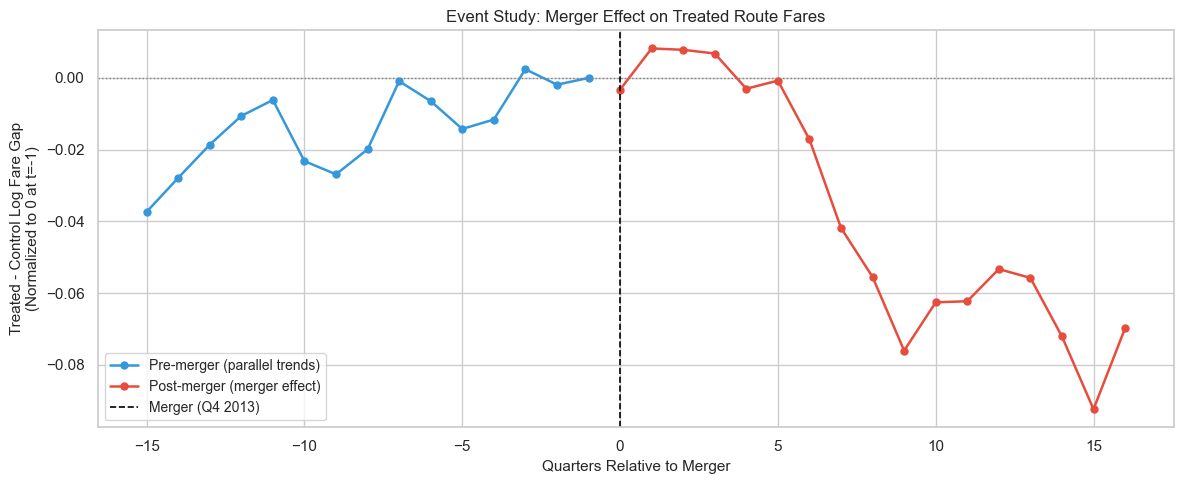

In [19]:
event_study = (
    panel.groupby(['event_time', 'treated'])['log_avg_fare']
    .mean().reset_index()
)
treated_es = event_study[event_study['treated'] == 1].set_index('event_time')['log_avg_fare']
control_es = event_study[event_study['treated'] == 0].set_index('event_time')['log_avg_fare']
gap      = (treated_es - control_es).dropna()
gap_norm = gap - gap.loc[-1]   # normalize to 0 at t = -1

print(f'Event study range : t={gap_norm.index.min()} to t={gap_norm.index.max()}')
pre_slope = np.polyfit(gap_norm[gap_norm.index < 0].index,
                       gap_norm[gap_norm.index < 0].values, 1)[0]
post_mean = gap_norm[gap_norm.index > 0].mean()
print(f'Event study range    : t={gap_norm.index.min()} to t={gap_norm.index.max()}')
print(f'Pre-merger slope     : {pre_slope:.5f} (near 0 supports parallel trends)')
print(f'Post-merger mean gap : {post_mean:.4f} log points  ({(np.exp(post_mean)-1)*100:.2f}%)')
print(f'Post-merger mean gap (vs pre): {gap_norm[gap_norm.index>0].mean():.4f} log points  ({(np.exp(gap_norm[gap_norm.index>0].mean())-1)*100:.2f}%)')

fig, ax = plt.subplots(figsize=(12, 5))
pre  = gap_norm[gap_norm.index < 0]
post = gap_norm[gap_norm.index >= 0]

ax.plot(pre.index,  pre.values,  color=CONTROL_COLOR, marker='o',
        markersize=5, linewidth=1.8, label='Pre-merger (parallel trends)')
ax.plot(post.index, post.values, color=TREATED_COLOR, marker='o',
        markersize=5, linewidth=1.8, label='Post-merger (merger effect)')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Merger (Q4 2013)')
ax.axhline(0, color='grey',  linestyle=':',  linewidth=1.0)
ax.set_xlabel('Quarters Relative to Merger', fontsize=11)
ax.set_ylabel('Treated - Control Log Fare Gap\n(Normalized to 0 at t=-1)', fontsize=11)
ax.set_title('Event Study: Merger Effect on Treated Route Fares', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'event_study.png', dpi=150)
plt.show()

---
## Section 7 — But-For Price and Consumer Damages

**Methodology:**
- **Overcharge** = actual fare - but-for fare, where but-for fare = actual fare / (1 + ATE%)
- **Route damages** = overcharge per passenger x total passengers on route-quarter
- **Total damages** = sum across all treated route-quarters in post period

The Double ML ATE is the primary causal estimate used here.

In [20]:
ate_log = float(dml_ate)
ate_pct = np.exp(ate_log) - 1
print(f'Estimated price overcharge (Double ML): {ate_pct*100:.2f}%')
print(f'Log-point estimate                    : {ate_log:.4f}')

Estimated price overcharge (Double ML): 2.57%
Log-point estimate                    : 0.0254


In [21]:
# But-for price and route-level damages
post_treated = panel[(panel['treated'] == 1) & (panel['post'] == 1)].copy()
post_treated['but_for_fare']       = post_treated['avg_fare'] / (1 + ate_pct)
post_treated['overcharge_per_pax'] = post_treated['avg_fare'] - post_treated['but_for_fare']
post_treated['route_damages']      = (
    post_treated['overcharge_per_pax'] * post_treated['total_passengers']
)

total_damages  = post_treated['route_damages'].sum()
total_pax      = post_treated['total_passengers'].sum()
avg_overcharge = post_treated['overcharge_per_pax'].mean()

print(f'Total consumer damages (2014-2017): ${total_damages/1e9:.2f} billion')
print(f'Total affected passengers         : {total_pax/1e6:.1f} million')
print(f'Average overcharge per ticket     : ${avg_overcharge:.2f}')

Total consumer damages (2014-2017): $3.97 billion
Total affected passengers         : 622.2 million
Average overcharge per ticket     : $6.73


In [22]:
# Route-level damages summary
route_damages = (
    post_treated.groupby('route').agg(
        total_damages    = ('route_damages',      'sum'),
        avg_overcharge   = ('overcharge_per_pax', 'mean'),
        total_passengers = ('total_passengers',   'sum'),
        avg_fare_actual  = ('avg_fare',           'mean'),
        avg_fare_but_for = ('but_for_fare',       'mean'),
    )
    .sort_values('total_damages', ascending=False)
    .reset_index()
)

print('Top 15 most-harmed routes:')
print(route_damages.head(15).to_string(index=False))

# Save damages artifacts before plotting
route_damages.to_parquet(ART_DIR / 'damages_summary.parquet', index=False)
joblib.dump({
    'ate_log':                  ate_log,
    'ate_pct':                  ate_pct,
    'total_damages_bn':         total_damages / 1e9,
    'total_passengers_mn':      total_pax / 1e6,
    'avg_overcharge_per_ticket': avg_overcharge,
}, ART_DIR / 'damages_scalars.pkl')
print('Saved: damages_summary.parquet, damages_scalars.pkl')

Top 15 most-harmed routes:
  route  total_damages  avg_overcharge  total_passengers  avg_fare_actual  avg_fare_but_for
LAX-JFK   5.840137e+07       11.738464         4961880.0       468.012860        456.274396
JFK-LAX   5.827576e+07       11.728361         4954770.0       467.610067        455.881706
JFK-SFO   3.771533e+07       10.857228         3468950.0       432.877955        422.020727
SFO-JFK   3.769786e+07       10.875458         3461980.0       433.604781        422.729323
EWR-SFO   2.697030e+07       12.130596         2216720.0       483.647166        471.516570
LGA-ORD   2.622557e+07        5.982328         4435390.0       238.515572        232.533244
ORD-LGA   2.610883e+07        5.919374         4458870.0       236.005609        230.086235
LAX-EWR   2.409270e+07       11.398783         2111980.0       454.469751        443.070968
EWR-LAX   2.351879e+07       11.304788         2079450.0       450.722171        439.417384
LAX-ORD   2.126884e+07        7.089885         305058

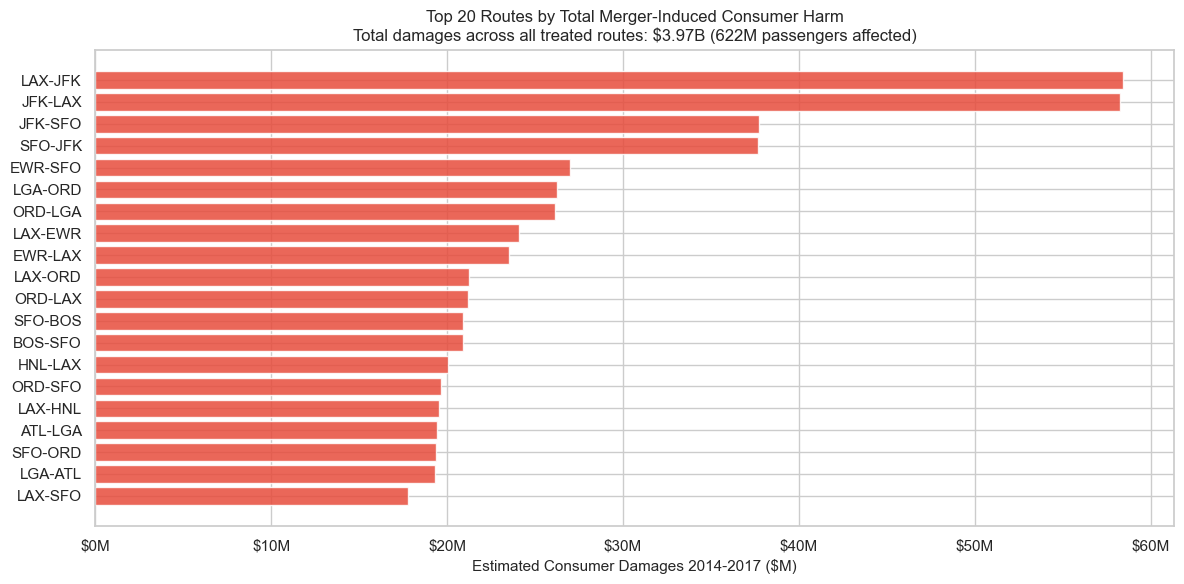

In [23]:
# Top 20 damaged routes bar chart
top20 = route_damages.head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20['route'][::-1], top20['total_damages'][::-1] / 1e6,
        color=TREATED_COLOR, alpha=0.85, edgecolor='white')
ax.set_xlabel('Estimated Consumer Damages 2014-2017 ($M)', fontsize=11)
ax.set_title(
    f'Top 20 Routes by Total Merger-Induced Consumer Harm\n'
    f'Total damages across all treated routes: ${total_damages/1e9:.2f}B '
    f'({total_pax/1e6:.0f}M passengers affected)',
    fontsize=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_route_damages.png', dpi=150)
plt.show()

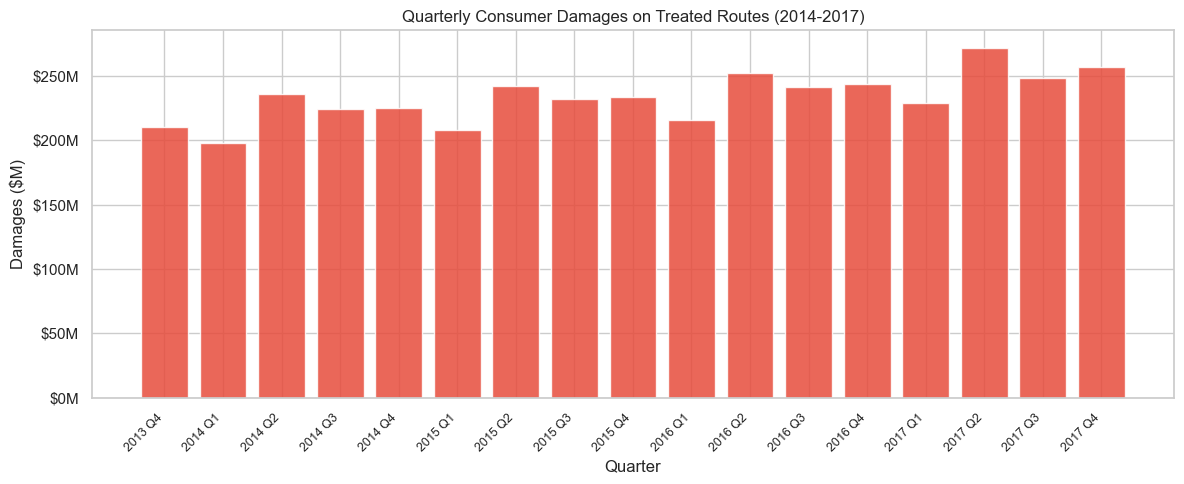

In [24]:
# Damages over time: post-merger quarters
qtr_damages = (
    post_treated.groupby('quarter_idx')
    .agg(
        total_damages    = ('route_damages',      'sum'),
        total_passengers = ('total_passengers',   'sum'),
    )
    .reset_index()
)
qtr_damages['year_label'] = qtr_damages['quarter_idx'].apply(
    lambda i: f'{2010 + i//4} Q{i%4+1}'
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(qtr_damages['year_label'], qtr_damages['total_damages'] / 1e6,
       color=TREATED_COLOR, alpha=0.85, edgecolor='white')
ax.set_title('Quarterly Consumer Damages on Treated Routes (2014-2017)', fontsize=12)
ax.set_xlabel('Quarter')
ax.set_ylabel('Damages ($M)')
ax.set_xticklabels(qtr_damages['year_label'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'quarterly_damages.png', dpi=150)
plt.show()

---
## Section 8 — Model Comparison Table

Side-by-side comparison of all four models. Double ML is the primary causal estimate; OLS and TWFE serve as baselines.

In [25]:
comparison = pd.DataFrame({
    'Model': [
        'Pooled OLS',
        'Two-Way Fixed Effects',
        'Double ML (LightGBM)',
        'Causal Forest (mean ITE)',
    ],
    'ATE (log points)': [
        round(ols_ate, 4),
        round(fe_ate, 4),
        round(float(dml_ate), 4),
        round(float(ite.mean()), 4),
    ],
    'ATE (% fare change)': [
        f'{(np.exp(ols_ate)-1)*100:.2f}%',
        f'{(np.exp(fe_ate)-1)*100:.2f}%',
        f'{(np.exp(float(dml_ate))-1)*100:.2f}%',
        f'{(np.exp(float(ite.mean()))-1)*100:.2f}%',
    ],
    'Controls': [
        'Fuel, CPI, distance, time trend',
        'Route FE + Time FE + fuel + competition',
        'LightGBM nuisance (all X_COLS)',
        'LightGBM nuisance (HET_COLS)',
    ],
    'Heterogeneity': [
        'No', 'No', 'No (ATE only)', 'Yes (ITE per route)',
    ],
})

print('MODEL COMPARISON TABLE')
print('=' * 80)
print(comparison.to_string(index=False))
print('=' * 80)

comparison.to_csv(ART_DIR / 'model_comparison.csv', index=False)
print('Saved: model_comparison.csv')

MODEL COMPARISON TABLE
                   Model  ATE (log points) ATE (% fare change)                                Controls       Heterogeneity
              Pooled OLS           -0.0277              -2.73%         Fuel, CPI, distance, time trend                  No
   Two-Way Fixed Effects           -0.0257              -2.54% Route FE + Time FE + fuel + competition                  No
    Double ML (LightGBM)            0.0254               2.57%          LightGBM nuisance (all X_COLS)       No (ATE only)
Causal Forest (mean ITE)            0.0438               4.48%            LightGBM nuisance (HET_COLS) Yes (ITE per route)
Saved: model_comparison.csv


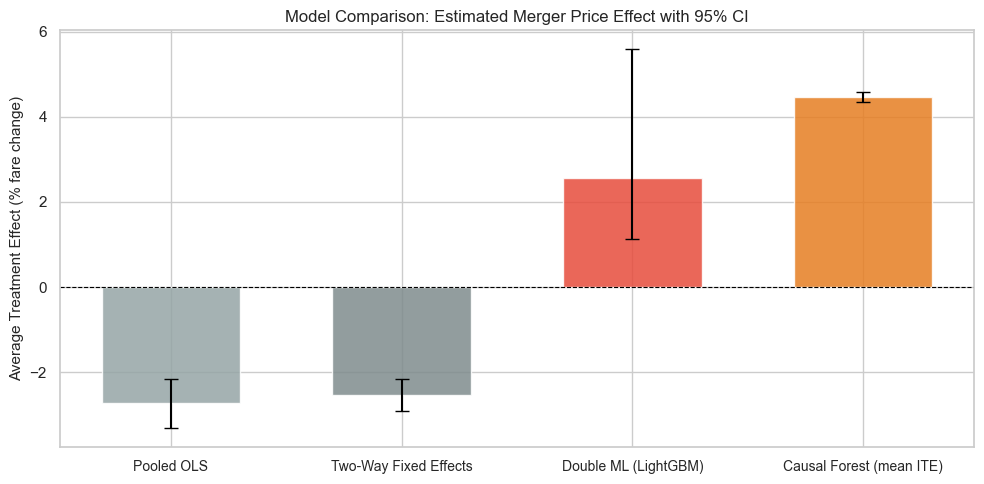

In [26]:
# Coefficient comparison plot
model_names  = comparison['Model'].tolist()
ates_log     = [
    ols_ate, fe_ate, float(dml_ate), float(ite.mean())
]
ates_pct     = [(np.exp(a) - 1) * 100 for a in ates_log]

# Approximate CIs (OLS and FE from model; DML from inference; CF use +/-1 std/sqrt(n))
ci_low_pct = [
    (np.exp(ols_ci[0]) - 1) * 100,
    (np.exp(fe_ci[0])  - 1) * 100,
    (np.exp(dml_ci_low)  - 1) * 100,
    (np.exp(float(ite.mean()) - 1.96 * float(ite.std()) / np.sqrt(len(ite))) - 1) * 100,
]
ci_high_pct = [
    (np.exp(ols_ci[1]) - 1) * 100,
    (np.exp(fe_ci[1])  - 1) * 100,
    (np.exp(dml_ci_high) - 1) * 100,
    (np.exp(float(ite.mean()) + 1.96 * float(ite.std()) / np.sqrt(len(ite))) - 1) * 100,
]
err_low  = [a - lo for a, lo in zip(ates_pct, ci_low_pct)]
err_high = [hi - a for a, hi in zip(ates_pct, ci_high_pct)]

colors = ['#95a5a6', '#7f8c8d', TREATED_COLOR, '#e67e22']
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(model_names))
bars = ax.bar(x_pos, ates_pct, color=colors, alpha=0.85, edgecolor='white', width=0.6)
ax.errorbar(x_pos, ates_pct, yerr=[err_low, err_high],
            fmt='none', color='black', capsize=5, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Average Treatment Effect (% fare change)', fontsize=11)
ax.set_title('Model Comparison: Estimated Merger Price Effect with 95% CI', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150)
plt.show()

---
## Section 9 — Results Summary and Artifacts Checklist

In [27]:
print('=' * 60)
print('  MODELING RESULTS SUMMARY')
print('=' * 60)
print(f'  OLS ATE      : {(np.exp(ols_ate)-1)*100:.2f}% fare increase')
print(f'  TWFE ATE     : {(np.exp(fe_ate)-1)*100:.2f}% fare increase')
print(f'  Double ML    : {(np.exp(float(dml_ate))-1)*100:.2f}% fare increase  <-- PRIMARY')
print(f'  Causal Forest: {(np.exp(float(ite.mean()))-1)*100:.2f}% (mean ITE)')
print()
print(f'  Total damages (2014-2017) : ${total_damages/1e9:.2f} billion')
print(f'  Affected passengers       : {total_pax/1e6:.1f} million')
print(f'  Avg overcharge per ticket : ${avg_overcharge:.2f}')
print('=' * 60)

  MODELING RESULTS SUMMARY
  OLS ATE      : -2.73% fare increase
  TWFE ATE     : -2.54% fare increase
  Double ML    : 2.57% fare increase  <-- PRIMARY
  Causal Forest: 4.48% (mean ITE)

  Total damages (2014-2017) : $3.97 billion
  Affected passengers       : 622.2 million
  Avg overcharge per ticket : $6.73


In [28]:
# Artifacts checklist
required_artifacts = [
    'ols_model.pkl',
    'fe_model.pkl',
    'dml_model.pkl',
    'cf_model.pkl',
    'damages_summary.parquet',
    'damages_scalars.pkl',
    'model_comparison.csv',
    'x_cols.pkl',
    'het_cols.pkl',
    'le_origin_state.pkl',
    'le_dest_state.pkl',
]

print('Artifact checklist:')
all_present = True
for artifact in required_artifacts:
    exists = (ART_DIR / artifact).exists()
    status = '[OK]     ' if exists else '[MISSING]'
    print(f'  {status}  {artifact}')
    if not exists:
        all_present = False

print()
if all_present:
    print('All artifacts present -- Flask API is ready to load models.')
else:
    print('WARNING: some artifacts missing -- re-run the relevant sections above.')

Artifact checklist:
  [OK]       ols_model.pkl
  [OK]       fe_model.pkl
  [OK]       dml_model.pkl
  [OK]       cf_model.pkl
  [OK]       damages_summary.parquet
  [OK]       damages_scalars.pkl
  [OK]       model_comparison.csv
  [OK]       x_cols.pkl
  [OK]       het_cols.pkl
  [OK]       le_origin_state.pkl
  [OK]       le_dest_state.pkl

All artifacts present -- Flask API is ready to load models.


In [ ]:
# Saved figures checklist
required_figures = [
    'shap_summary.png', 'shap_beeswarm.png',
    'ite_distribution.png', 'ite_vs_distance.png', 'ite_vs_carriers.png',
    'event_study.png',
    'top_route_damages.png', 'quarterly_damages.png',
    'model_comparison.png',
]

print('Figure checklist:')
for fig_name in required_figures:
    exists = (FIG_DIR / fig_name).exists()
    status = '[OK]     ' if exists else '[MISSING]'
    print(f'  {status}  {fig_name}')

Figure checklist:
  [OK]       shap_summary.png
  [OK]       shap_beeswarm.png
  [OK]       ite_distribution.png
  [OK]       ite_vs_distance.png
  [OK]       ite_vs_carriers.png
  [OK]       event_study.png
  [OK]       top_route_damages.png
  [OK]       quarterly_damages.png
  [OK]       model_comparison.png


: 

---
## Next Steps

All model artifacts are saved to `models/artifacts/`. The Flask API (`api/app.py`) will load them at startup:

```python
dml_model  = joblib.load('models/artifacts/dml_model.pkl')
x_cols     = joblib.load('models/artifacts/x_cols.pkl')
het_cols   = joblib.load('models/artifacts/het_cols.pkl')
scalars    = joblib.load('models/artifacts/damages_scalars.pkl')
le_origin  = joblib.load('models/artifacts/le_origin_state.pkl')
le_dest    = joblib.load('models/artifacts/le_dest_state.pkl')
```

**API endpoints to build:**
- `GET /health` — liveness check
- `POST /predict` — route-level ATE prediction
- `GET /damages` — return pre-computed damages summary
- `GET /routes` — list all treated routes with ITE

**Streamlit app:** Route Explorer, Damages Calculator, Heterogeneity Map